In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_parquet(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\optimized_df.parquet")
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


In [4]:
df.memory_usage(deep=True).sum()

np.int64(2844826)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            38043 non-null  Int16   
 1   Gender                         40000 non-null  category
 2   Country                        40000 non-null  category
 3   City                           40000 non-null  category
 4   Membership_Years               40000 non-null  float32 
 5   Login_Frequency                40000 non-null  int8    
 6   Session_Duration_Avg           37142 non-null  float32 
 7   Pages_Per_Session              37609 non-null  float32 
 8   Cart_Abandonment_Rate          40000 non-null  float32 
 9   Wishlist_Items                 36792 non-null  Int8    
 10  Total_Purchases                40000 non-null  float32 
 11  Average_Order_Value            40000 non-null  float32 
 12  Days_Since_Last_Purchase       3

### BIVARIATE ANALYSIS
##### How does this feature affect churn?
##### There are mainly 2 cases
* Continuous/Discrete Numerical - Numerical vs Target
* Main goal - Do churned and non-churned customers behave differently?
* Categorical                   - Categorical vs Target
* main goal - Which categories churn more?

In [6]:
df["Churned"].value_counts()

Churned
0    25550
1    14450
Name: count, dtype: int64

In [44]:
class BiVariate():
    def __init__(self,df,col,target="Churned"):
        self.df = df
        self.col = col
        self.target = target
        self.continuous_discrete_cols = ["Age",'Membership_Years','Session_Duration_Avg',
                                'Pages_Per_Session','Cart_Abandonment_Rate','Total_Purchases','Average_Order_Value',
                                'Discount_Usage_Rate','Returns_Rate','Email_Open_Rate','Social_Media_Engagement_Score',
                                'Mobile_App_Usage','Lifetime_Value','Days_Since_Last_Purchase','Credit_Balance',"aa"]
        self.discrete_cols = ["Product_Reviews_Written","Login_Frequency","Wishlist_Items","Customer_Service_Calls"]
        self.categorical_cols = ['Gender', 'Country', 'City', 'Signup_Quarter','Payment_Method_Diversity']

    def summary_stats(self):
        print(self.df.groupby(self.target)[self.col].agg(["mean","median","std","min","max"]))


    def crosstab(self):
        print(pd.crosstab(self.df[self.col],self.df[self.target],normalize="index")*100)
    def boxplot(self):
        sns.boxplot(data=self.df,x=self.target,y=self.col)
        plt.title(f"{self.col} vs {self.target}")
        plt.show()

    def histogram(self):
        sns.histplot(data=self.df,x=self.col,hue=self.target,kde=True,element="step")
        plt.title(f"{self.col} Distribution by {self.target}")
        plt.show()
        
    def countplot(self):
        sns.countplot(data=self.df,x=self.col,hue=self.target)
        plt.title(f"{self.col} Count by {self.target}")
        plt.xticks(rotation=45)
        plt.show()

    
    def two(self):
        figure,axes = plt.subplots(1,2,figsize=(12,4))
        sns.histplot(data=self.df,x=self.col,hue=self.target,color="cornflowerblue",kde=True,bins=50,ax=axes[0])
        axes[0].set_title(f"{self.col} Distribution by {self.target}")
        axes[0].set_xlabel(self.col)
        axes[0].set_ylabel(self.target)
        
        sns.boxplot(data=self.df,x=self.target,y=self.col,ax=axes[1])
        axes[1].set_title(f"{self.col} vs {self.target}")
        axes[1].set_xlabel(self.target)
        axes[1].set_ylabel(self.col)
        

        plt.show()

    def two_discrete(self):
        figure,axes = plt.subplots(1,2,figsize=(12,4))
        sns.histplot(data=self.df,x=self.col,hue=self.target,color="cornflowerblue",kde=False,bins=50,discrete=True,ax=axes[0])
        axes[0].set_title(f"{self.col} Distribution by {self.target}")
        axes[0].set_xlabel(self.col)
        axes[0].set_ylabel(self.target)
        
        sns.boxplot(data=df,x=self.target,y=self.col,ax=axes[1])
        axes[1].set_title(f"{self.col} vs {self.target}")
        axes[1].set_xlabel(self.target)
        axes[1].set_ylabel(self.col)
        

        plt.show()

    def flow(self):
        if self.col in self.continuous_discrete_cols:
            self.summary_stats()
            self.two()
        elif self.col in self.discrete_cols:
            self.summary_stats()
            self.two_discrete()
        else:
            self.crosstab()
            self.countplot()
            

              mean  median        std  min  max
Churned                                        
0          38.5464    38.0  11.446711    5  200
1        35.902598    36.0  12.422674    5  200


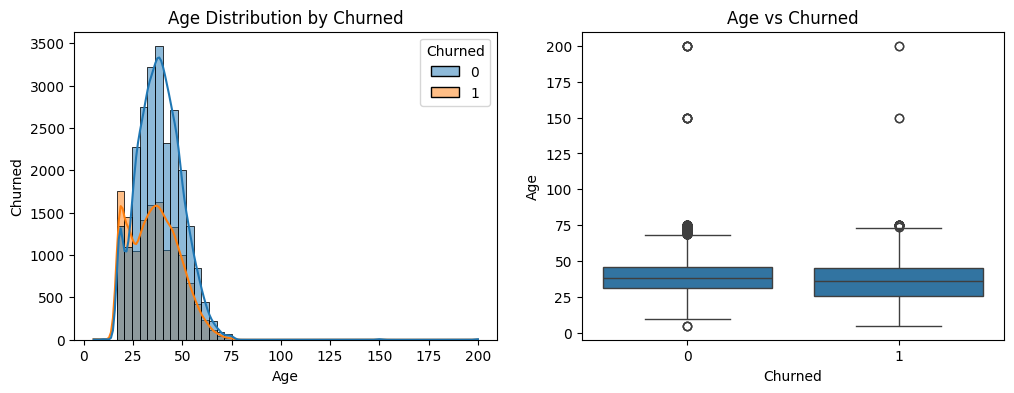

In [45]:
o = BiVariate(df,"Age")
o.flow()

### Insights
* From histogram, both groups overlap heavily
* Age distributions are very similar
* so age alone may not strongly seperate churns.
* in boxplots, medians are soo close, spreead is similar,
* this suggests weak standalone churn seperation.
* Extreme age outliers (150+) are observed in both churn groups and may require further preprocessing or business validation.
* Age may contribute limited standalone predictive power, though it can still provide value when combined with other behavioral features.

Churned          0          1
Gender                       
Female   63.716594  36.283406
Male     64.155465  35.844535
Other    60.933333  39.066667


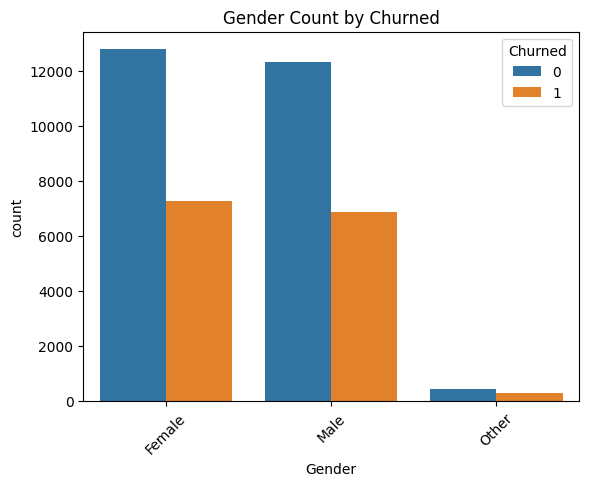

In [46]:
o = BiVariate(df,"Gender")
o.flow()

### Insights
* 

Churned            0          1
Country                        
Australia  63.289991  36.710009
Canada     63.273785  36.726215
France     66.099071  33.900929
Germany    64.105157  35.894843
India      63.119797  36.880203
Japan      65.665860  34.334140
UK         63.801736  36.198264
USA        63.555107  36.444893


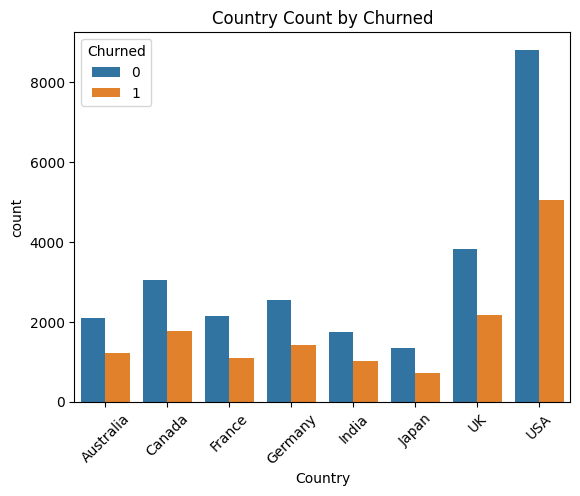

In [47]:
o = BiVariate(df,"Country")
o.flow()

### Insights
* Churn rates across countries appear relatively similar, ranging approximately between 34%–37%.
* No country exhibits an exceptionally high or low churn rate compared to others.
* India and Canada show slightly higher churn percentages, while France and Japan exhibit comparatively lower churn rates.
* Geographic location alone may not strongly influence customer churn behavior in this dataset.
* Behavioral and engagement-related features may provide stronger predictive signals than country-based demographic information.
* Although country may have limited standalone predictive power, it can still contribute useful interaction effects during modeling.

Churned              0          1
City                             
Adelaide     67.732116  32.267884
Bangalore    64.944649  35.055351
Berlin       63.625154  36.374846
Birmingham   63.110008  36.889992
Brisbane     63.787879  36.212121
Calgary      62.303665  37.696335
Chennai      66.722130  33.277870
Chicago      64.005753  35.994247
Cologne      63.030303  36.969697
Delhi        60.966543  39.033457
Frankfurt    66.713092  33.286908
Glasgow      63.283319  36.716681
Hamburg      62.936221  37.063779
Houston      63.362832  36.637168
Hyderabad    61.016949  38.983051
Kyoto        62.997658  37.002342
Leeds        62.572135  37.427865
London       63.706234  36.293766
Los Angeles  63.499079  36.500921
Lyon         65.591398  34.408602
Manchester   66.192733  33.807267
Marseille    63.207547  36.792453
Melbourne    60.371517  39.628483
Montreal     62.246964  37.753036
Mumbai       61.524501  38.475499
Munich       64.591440  35.408560
Nagoya       67.245658  32.754342
New York     6

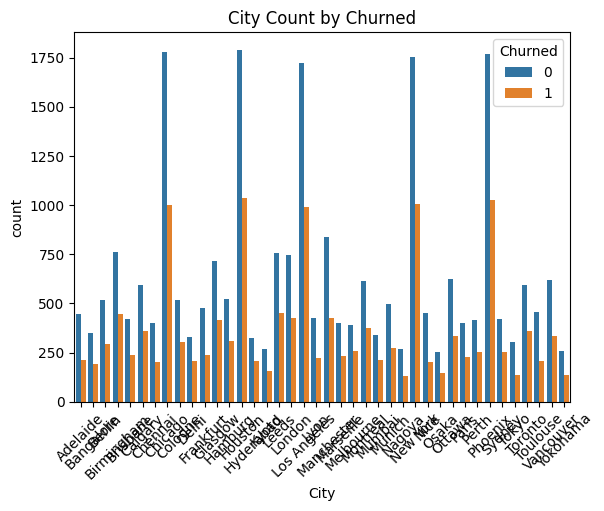

In [11]:
o = BiVariate(df,"City")
o.flow()

Churned                 0          1
Signup_Quarter                      
Q1              63.358089  36.641911
Q2              63.188664  36.811336
Q3              64.149428  35.850572
Q4              64.810735  35.189265


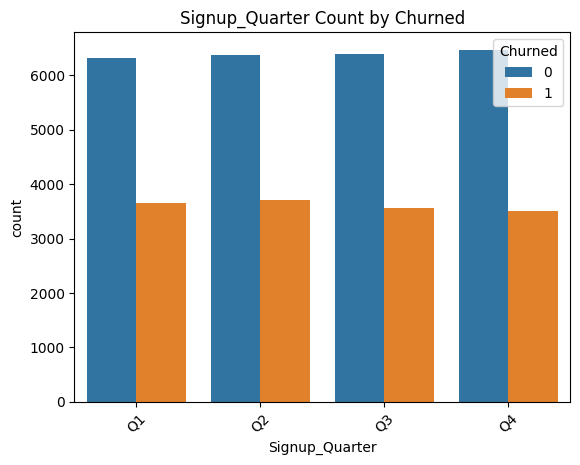

In [12]:
o = BiVariate(df,"Signup_Quarter")
o.flow()

             mean  median       std  min   max
Churned                                       
0        2.992084     2.5  2.069836  0.1  10.0
1        2.981996     2.5  2.047075  0.1  10.0


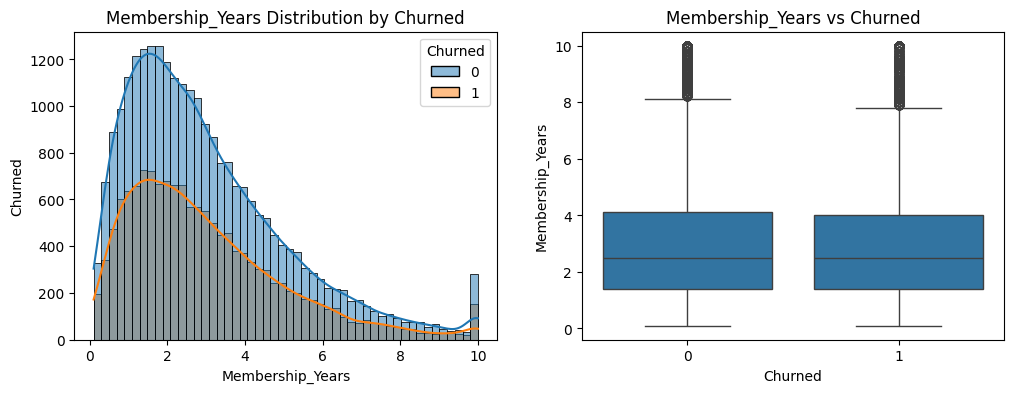

In [48]:
o = BiVariate(df,"Membership_Years")
o.flow()

### Insights
* Churned and retained customers exhibit nearly identical central tendencies and spread for this feature.
* Mean, median, and standard deviation values are highly similar across both churn groups.
* The feature may have limited standalone influence on churn behavior.
* Additional interaction analysis or model-based feature importance evaluation is recommended before deciding on feature removal.

              mean     median        std  min        max
Churned                                                 
0        29.207027  28.200001  10.479804  1.0  75.599998
1        23.686823  22.000000  10.907314  1.0  66.300003


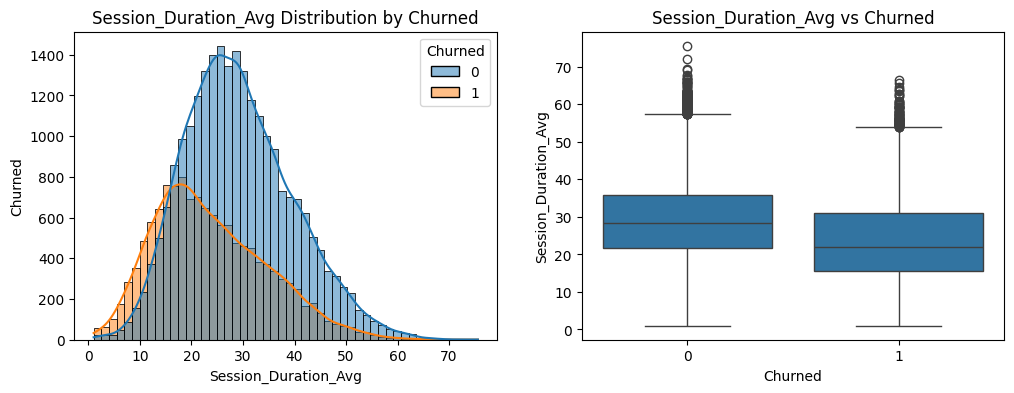

In [14]:
o = BiVariate(df,"Session_Duration_Avg")
o.flow()

### Insights
* Retained customers exhibit noticeably higher average session durations compared to churned customers.
* Churned customers spend significantly less time interacting with the platform on average.
* Median session duration is also lower for churned customers, indicating reduced engagement behavior.
* Distribution plots show visible separation between churned and retained customer groups.
* Lower session duration may indicate declining platform engagement, reduced customer interest, or weaker interaction behavior.
* Session duration appears to be a strong behavioral indicator for churn prediction and may contribute significant predictive value during modeling.

             mean  median       std  min        max
Churned                                            
0        9.315260     9.0  3.665339  1.0  24.100000
1        7.366206     6.9  3.730805  1.0  23.200001


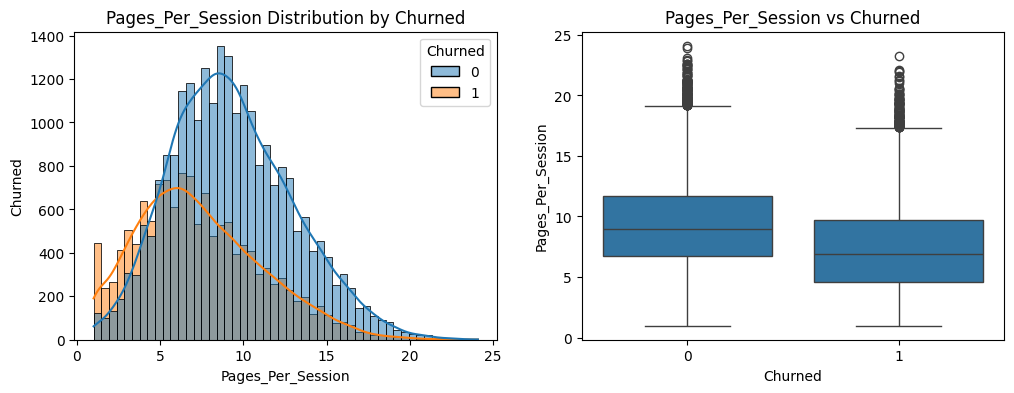

In [15]:
o = BiVariate(df,"Pages_Per_Session")
o.flow()

### Insights
* Retained customers browse significantly more pages per session compared to churned customers.
* Churned customers exhibit lower average and median page interaction behavior.
* Distribution plots show a noticeable leftward shift for churned users, indicating reduced browsing activity.
* Customers with lower page exploration behavior may demonstrate weaker engagement and reduced platform interest.
* Higher page interaction levels appear associated with stronger customer retention.
* Pages per session may serve as an important engagement-based predictor for churn modeling.

              mean     median        std  min         max
Churned                                                  
0        54.164894  55.500000  15.181079  0.0  143.743347
1        64.178932  66.599998  16.813997  0.0  134.957474


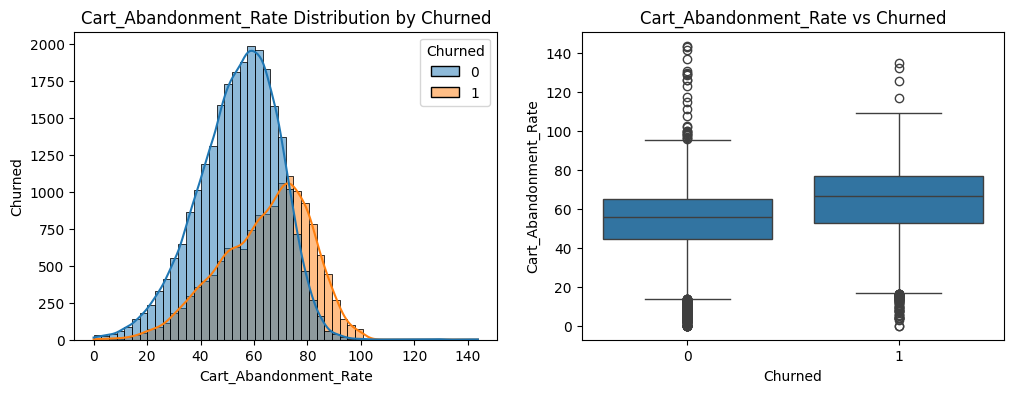

In [16]:
o = BiVariate(df,"Cart_Abandonment_Rate")
o.flow()

### Insights
* Churned customers exhibit significantly higher cart abandonment rates compared to retained customers.
* Both mean and median cart abandonment values are noticeably higher for churned users.
* Distribution plots show a clear rightward shift for churned customers, indicating stronger abandonment behavior.
* Customers with higher cart abandonment rates may demonstrate lower purchase commitment or declining buying intent.
* Frequent cart abandonment can reflect dissatisfaction, pricing concerns, checkout friction, or reduced engagement quality.
* Cart abandonment rate appears to be a strong behavioral indicator of churn and may contribute substantial predictive value during modeling.

              mean  median       std   min         max
Churned                                               
0        13.817590    13.0  6.842557 -11.7  127.400002
1        11.350201    10.0  7.006322 -13.0  124.800003


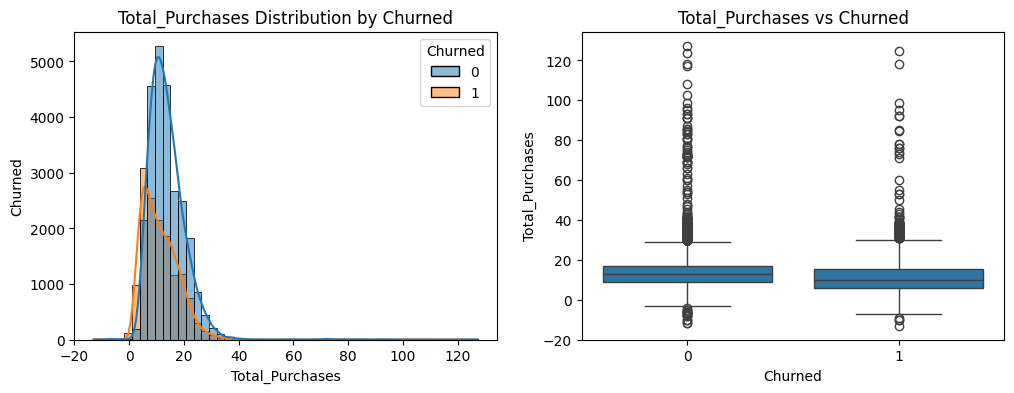

In [17]:
o = BiVariate(df,"Total_Purchases")
o.flow()

### Insights
* Histogram Interpretation
* The churned customer distribution:
* shifts toward lower purchase counts.

* Meaning:

* churners buy less frequently
* reduced purchasing behavior exists
* compared to retained users.

* Boxplot Interpretation

* Compared to retained customers:

* churned customers have lower median purchases.
* lower central concentration
* reduced purchasing

             mean    median       std       min       max
Churned                                                  
0        4.692761  4.699480  0.373912  3.361070  9.176513
1        4.814299  4.831469  0.386471  3.327551  9.157828


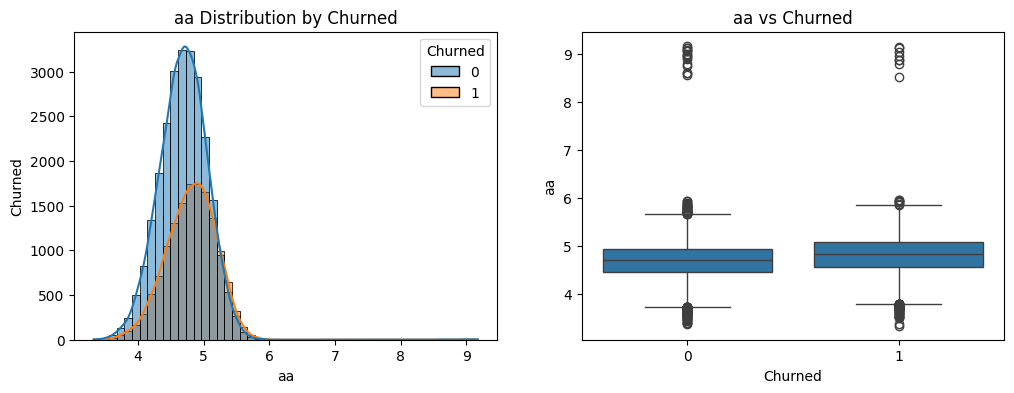

In [19]:
df["aa"] = np.log1p(df["Average_Order_Value"])
# sns.histplot(np.log1p(df["aa"]),kde=True)
o = BiVariate(df,"aa")
# plt.xlim(0, 500)
o.flow()

### Insights
* Visualizations are dominated by outliers.
* After reducing the effect of extreme outliers, the distribution became more * balanced and easier to analyze.
* Churned customers still show slightly higher average order values compared to retained customers.
* Some customers may place expensive orders but still stop using the platform later.
* Higher spending alone does not guarantee customer retention.
* Log transformation helped improve visualization and reduced the impact of extreme values.

              mean     median        std  min         max
Churned                                                  
0        43.063854  41.599998  21.249588  0.5  116.160004
1        39.424374  36.400002  21.506697  0.6  114.720001


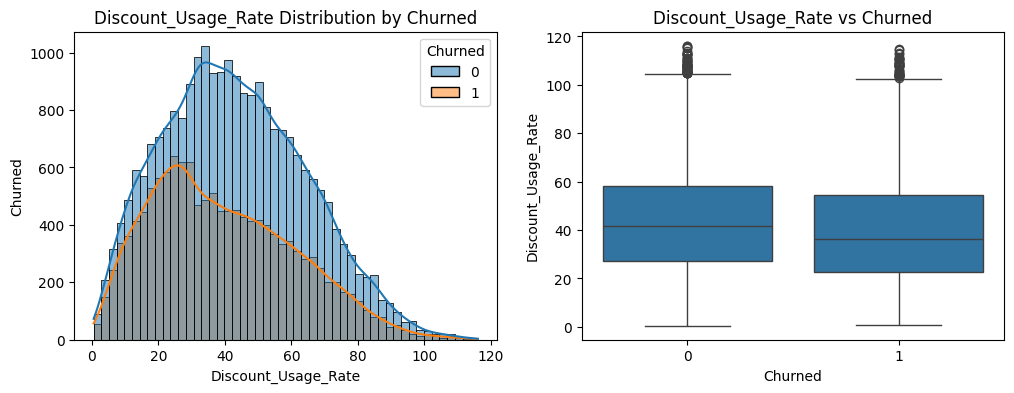

In [20]:
o = BiVariate(df,"Discount_Usage_Rate")
o.flow()

### Insights
* Retained customers use discounts and promotional offers slightly more than churned customers.
* Customers actively using offers and discounts appear more engaged with the platform.
* Lower discount usage may indicate reduced shopping interest or lower customer engagement.
* Discount usage shows a moderate relationship with customer retention.
* Some customers have discount usage values above 100, which may require further business validation or checking of calculation methods.

             mean  median       std  min        max
Churned                                            
0        6.447841     5.2  6.150392  0.0  98.886353
1        7.204272     6.0  5.992309  0.0  99.615730


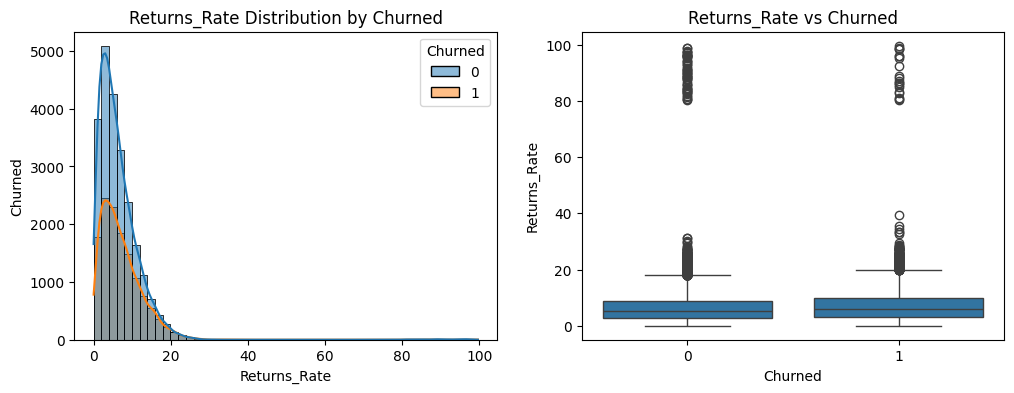

In [21]:
o = BiVariate(df,"Returns_Rate")
o.flow()

### Insights
* Churned customers tend to return products slightly more often compared to retained customers.
* Higher product returns may indicate customer dissatisfaction or poor product experience.
* Customers with frequent returns appear more likely to leave the platform.
* Some customers in both groups show extremely high return behavior.
* Return behavior has a moderate relationship with customer churn.
* Combining return behavior with engagement and purchase activity can help better identify churn risk.

              mean     median        std  min        max
Churned                                                 
0        22.909298  21.799999  13.924865  0.0  81.199997
1        15.893607  13.400000  13.932031  0.0  85.699997


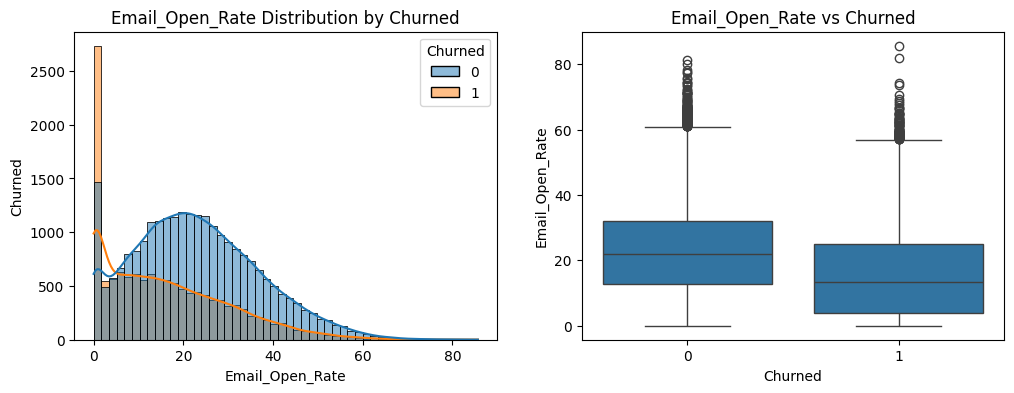

In [22]:
o = BiVariate(df,"Email_Open_Rate")
o.flow()

### Insights
* Retained customers open emails more frequently compared to churned customers.
* Churned customers generally show very low email engagement.
* Customers who actively interact with promotional emails are more likely to stay with the platform.
* Low email activity may indicate declining customer interest and reduced engagement.
* Many churned customers rarely open emails, showing strong disengagement before leaving the platform.
* Email engagement is a strong indicator of customer retention behavior.

              mean  median        std  min    max
Churned                                          
0        31.920628    30.5  20.384880  0.0  100.0
1        23.159184    19.9  19.788717  0.0  100.0


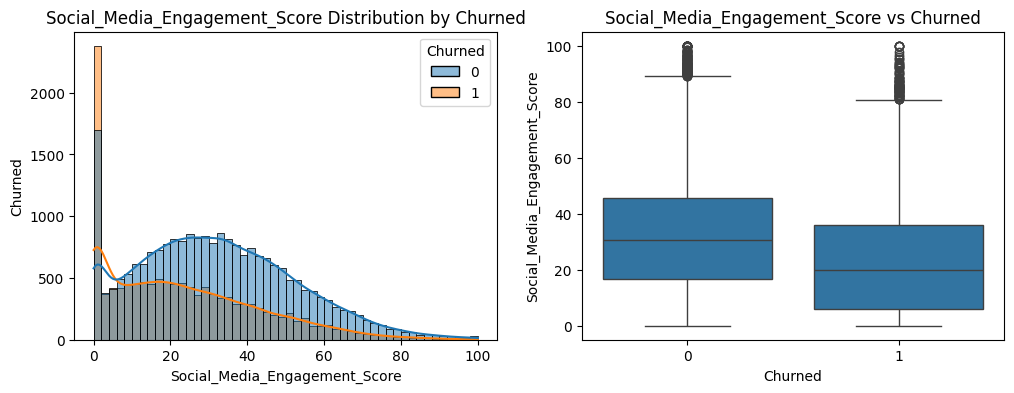

In [23]:
o = BiVariate(df,"Social_Media_Engagement_Score")
o.flow()

### Insights
* Retained customers show higher social media engagement compared to churned customers.
* Churned customers generally interact less with the platform on social media.
* Customers who actively engage with social media content are more likely to stay with the platform.
* Lower social media activity may indicate declining customer interest and weaker brand connection.
* Social media engagement shows a meaningful relationship with customer retention behavior.
* Reduced customer engagement across digital channels is a strong sign of possible churn.

              mean  median       std  min        max
Churned                                             
0        20.717472    20.0  9.149385  0.0  61.900002
1        16.080265    14.7  9.346246  0.0  56.900002


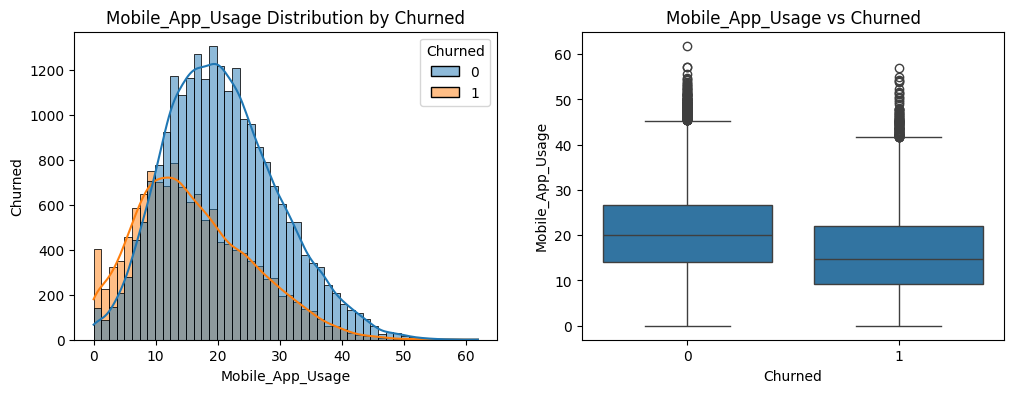

In [24]:
o = BiVariate(df,"Mobile_App_Usage")
o.flow()

### Insights
* Retained customers use the mobile app more frequently compared to churned customers.
* Churned customers generally show lower app activity and engagement.
* Customers who interact with the app regularly are more likely to stay with the platform.
* Lower app usage may indicate declining customer interest and reduced shopping activity.
* Mobile app engagement shows a strong relationship with customer retention.
Reduced customer engagement is a strong warning sign of possible churn.

                mean       median          std  min          max
Churned                                                         
0        1447.481812  1266.515015   858.046814  0.0  7990.069824
1        1425.423218  1132.729980  1019.343689  0.0  8987.240234


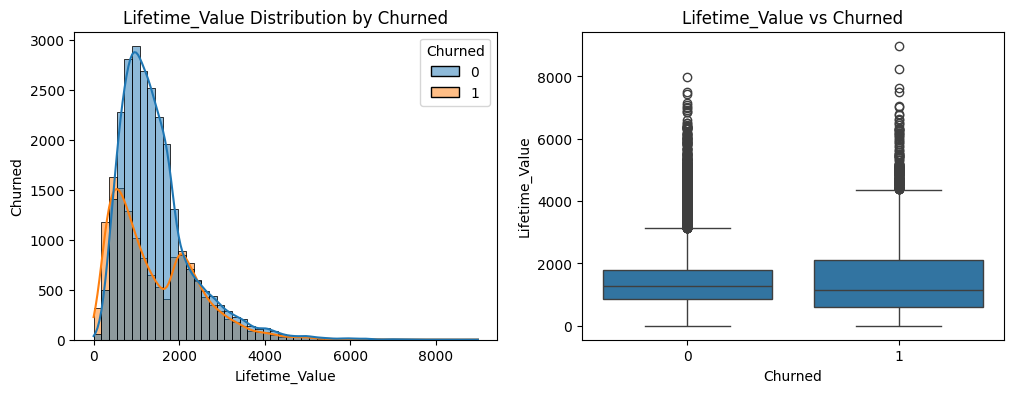

In [25]:
o = BiVariate(df,"Lifetime_Value")
o.flow()

### Insights
* Retained customers generally contribute slightly higher lifetime value compared to churned customers.
* Customers who stay longer with the platform tend to generate more long-term revenue.
* Some churned customers still show very high lifetime values, indicating that even valuable customers can leave the platform.
* Customer value alone may not guarantee retention; engagement and satisfaction also play important roles.
* Lifetime value can help businesses identify high-value customers who should be prioritized in retention strategies.

              mean  median        std  min  max
Churned                                        
0        26.955429    19.0  26.634562    0  257
1        36.942135    26.0  35.166901    0  287


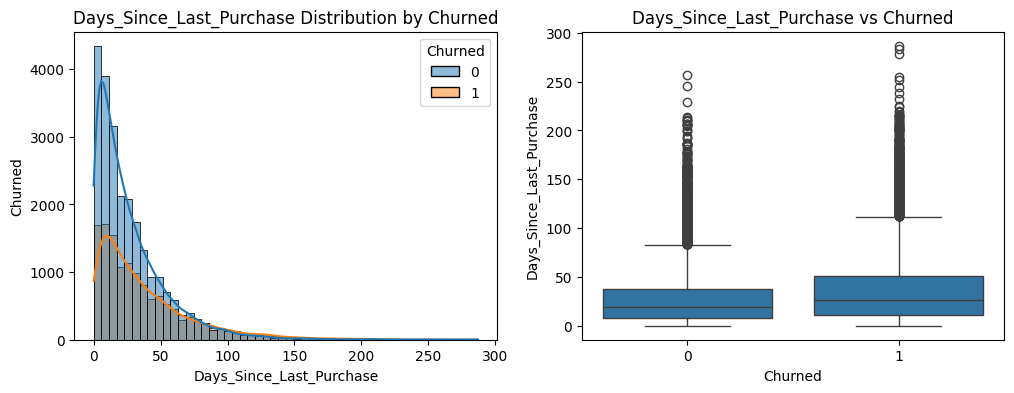

In [49]:
o = BiVariate(df,"Days_Since_Last_Purchase")
o.flow()

### Insights
* Churned customers usually have not purchased anything for a longer time.
* Customers who stop purchasing for many days are more likely to leave the platform.
* Retained customers tend to purchase more recently and more regularly.
* Long inactivity is a strong sign of declining customer engagement.
* This feature can help businesses identify inactive customers early and target them with re-engagement offers or reminders.

                mean  median          std  min   max
Churned                                             
0        2088.056298  2026.5  1217.734003    0  6987
1        1664.203585  1558.0  1200.097767    0  7160


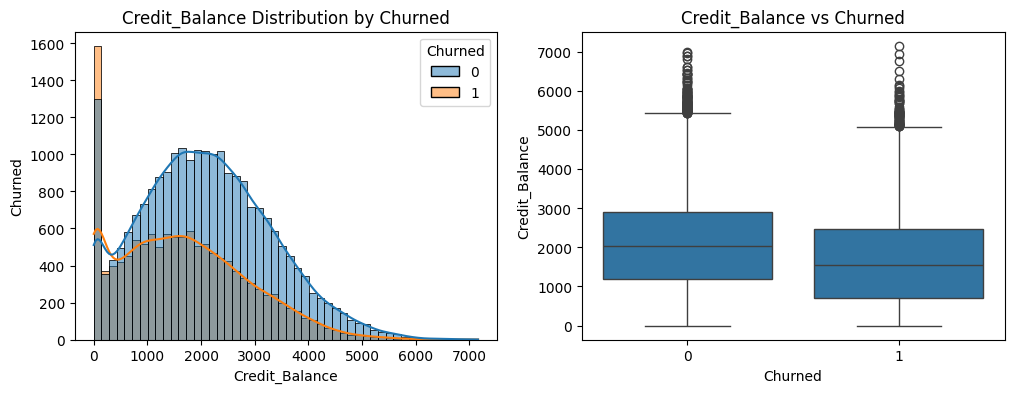

In [28]:
o = BiVariate(df,"Credit_Balance")
o.flow()

### Insights
* Retained customers generally maintain higher credit balances compared to churned customers.
* Churned customers tend to have lower average and median credit balances.
* Customers with higher account balances may be more financially engaged with the platform.
* Lower credit balance may indicate reduced usage, lower spending activity, or declining engagement.
* Credit balance shows a meaningful relationship with customer retention behavior.
* Customers with higher credit balances appear less likely to churn. Remaining wallet balance or unused credits may encourage continued platform engagement and future purchases. Businesses can leverage this behavior through personalized reminder campaigns and retention offers.

              mean  median       std  min  max
Churned                                       
0        12.626262    12.0  7.696380    0   46
1         9.120830     8.0  7.539726    0   43


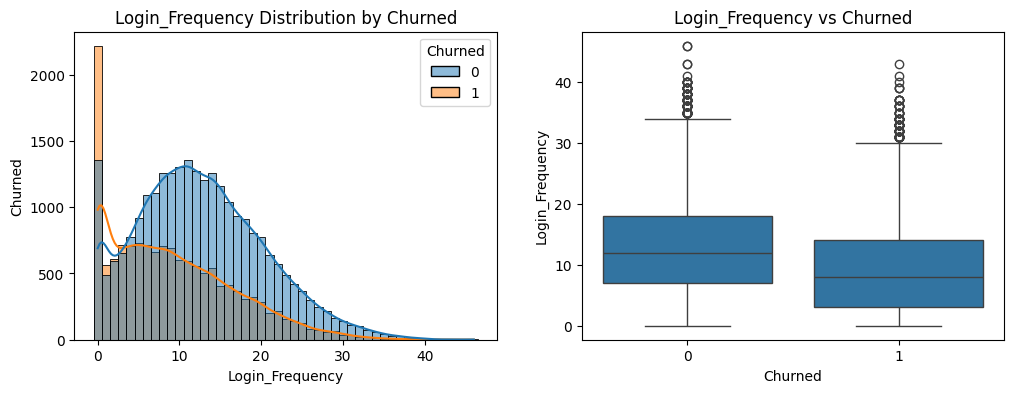

In [41]:
o = BiVariate(df,"Login_Frequency")
o.flow()

### Insights
* Retained customers log in to the platform more frequently compared to churned customers.
* Churned customers generally show lower platform activity and engagement.
* Customers who interact with the platform regularly are more likely to remain retained.
* Lower login frequency may indicate declining interest or reduced customer engagement before churn.
* Login frequency appears to be a strong behavioral indicator related to customer retention.

             mean  median       std  min  max
Churned                                      
0        4.709234     4.0  3.171859    0   28
1        3.309133     3.0  3.029347    0   19


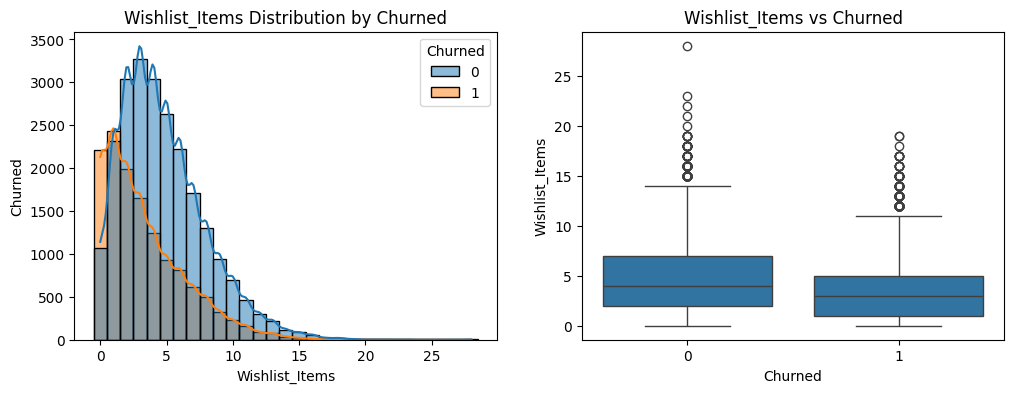

In [40]:
o = BiVariate(df,"Wishlist_Items")
o.flow()

### Insights
* Retained customers tend to keep more items in their wishlist compared to churned customers.
* Customers with higher wishlist activity appear more engaged with the platform.
* Churned customers generally show lower wishlist interaction and browsing interest.
* Adding products to wishlist may indicate stronger customer interest and future purchase intent.
* Wishlist activity shows a meaningful relationship with customer retention.

             mean  median       std  min  max
Churned                                      
0        5.171906     5.0  2.531744    0   18
1        6.904378     7.0  2.612304    0   21


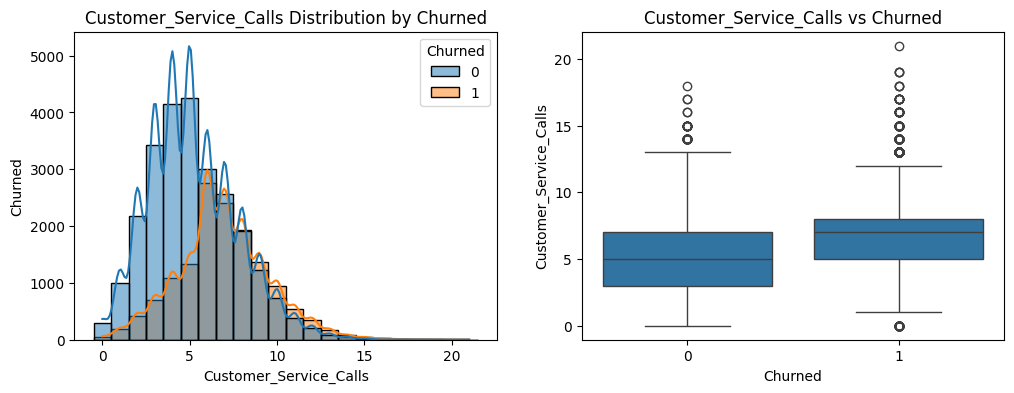

In [37]:
o = BiVariate(df,"Customer_Service_Calls")
o.flow()

### Insights
* Churned customers contact customer support more frequently compared to retained customers.
* Customers with higher customer service calls appear more likely to churn.
* Frequent support calls may indicate dissatisfaction, unresolved issues, or poor customer experience.
* Customers requiring fewer support interactions tend to remain more retained.
* Customer service interaction behavior shows a meaningful relationship with churn.

             mean  median       std  min  max
Churned                                      
0        3.126351     3.0  2.318831    0   16
1         2.18994     2.0  2.193839    0   15


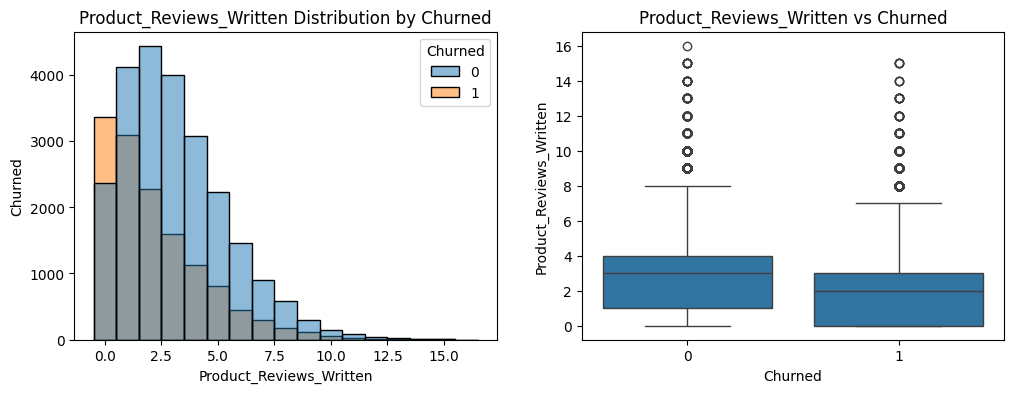

In [43]:
o = BiVariate(df,"Product_Reviews_Written")
o.flow()

### Insights
* Retained customers write more product reviews on average compared to churned customers.
* Churned customers generally show lower review activity and engagement.
* Customers actively writing reviews may be more connected and engaged with the platform.
* Lower review participation may indicate reduced customer involvement or declining interest.
* Product review activity appears to have a meaningful relationship with customer retention.

Churned                           0          1
Payment_Method_Diversity                      
1                         63.160132  36.839868
2                         64.775963  35.224037
3                         63.512945  36.487055
4                         63.431451  36.568549
5                         62.430097  37.569903


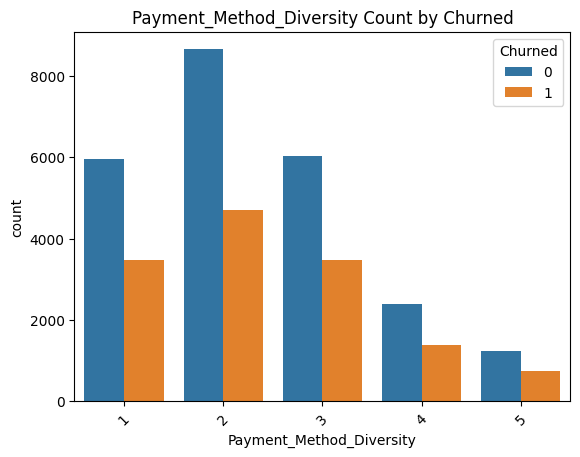

In [26]:
o = BiVariate(df,"Payment_Method_Diversity")
o.flow()

### Insights
* Most customers use 2–3 payment methods.
* Customers using 2 payment methods show slightly lower churn compared to other groups.
* Customers using 5 payment methods have the highest churn rate, though this group contains fewer customers.
* Overall, churn differences across payment method groups are relatively small.
* Payment method diversity alone may not strongly influence churn behavior.

# Feature vs Feature analysis
#### First let us divide them into groups and do analyze inside grouos first


A) Customer Demographics

Who they are

* Age
* Gender
* Country
* City
  
B) Engagement Features

How active they are

* Login_Frequency
* Session_Duration_Avg
* Pages_Per_Session
* Mobile_App_Usage
* Social_Media_Engagement_Score
* Email_Open_Rate

C) Purchase Behavior

How they buy

* Total_Purchases
* Average_Order_Value
* Cart_Abandonment_Rate
* Wishlist_Items
* Discount_Usage_Rate
* Payment_Method_Diversity

D) Loyalty / Relationship

How connected they are

* Membership_Years
* Days_Since_Last_Purchase
* Customer_Service_Calls
* Product_Reviews_Written
* Returns_Rate

E) Business Value

How valuable they are

* Lifetime_Value
* Credit_Balance

Best Practical Flow For YOU
Phase 1

Already completed:

Uni
Feature vs Target
Phase 2 (Now)

Same-group feature relationships

Phase 3

Cross-group business analysis

Phase 4

Correlation + multivariate patterns

Phase 5

Customer segmentation

Example:

High engagement + low purchase
High value + high churn risk
Low activity + high abandonment

### Customer demographics
#### Demographics vs behaviors

In [53]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,18,25,35,45,60,100],
    labels=["Teen","Young Adult","Adult","Mid Age","Senior","Old"]
)

In [54]:

df.groupby("Age_Group")["Total_Purchases"].mean()

C:\Users\91891\AppData\Local\Temp\ipykernel_7668\885503252.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Total_Purchases"].mean()


Age_Group
Teen           13.024414
Young Adult    13.078146
Adult          12.864789
Mid Age        12.935155
Senior         12.921824
Old            12.687246
Name: Total_Purchases, dtype: float32

<Axes: xlabel='Gender', ylabel='Total_Purchases'>

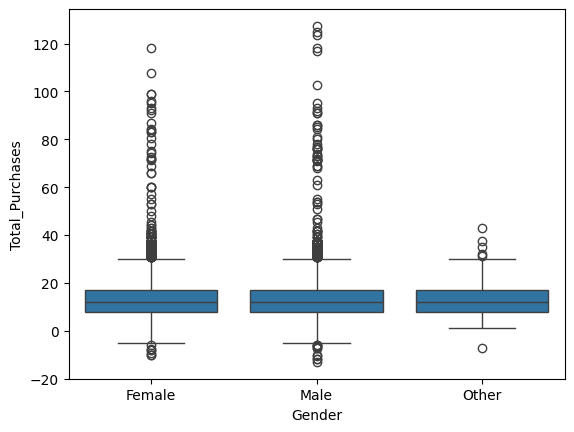

In [57]:
sns.boxplot(data=df,x="Gender",y="Total_Purchases")

In [58]:
df.groupby("Age_Group")["Average_Order_Value"].mean()

C:\Users\91891\AppData\Local\Temp\ipykernel_7668\1642222169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Average_Order_Value"].mean()


Age_Group
Teen           124.858307
Young Adult    127.750618
Adult          126.385269
Mid Age        124.418907
Senior         124.846817
Old            120.423744
Name: Average_Order_Value, dtype: float32

In [59]:
df.groupby("Age_Group")["Average_Order_Value"].median()


C:\Users\91891\AppData\Local\Temp\ipykernel_7668\614452138.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Average_Order_Value"].median()


Age_Group
Teen           114.209999
Young Adult    113.095001
Adult          114.809998
Mid Age        113.709999
Senior         113.419998
Old            112.650002
Name: Average_Order_Value, dtype: float32

<Axes: xlabel='Age_Group', ylabel='Average_Order_Value'>

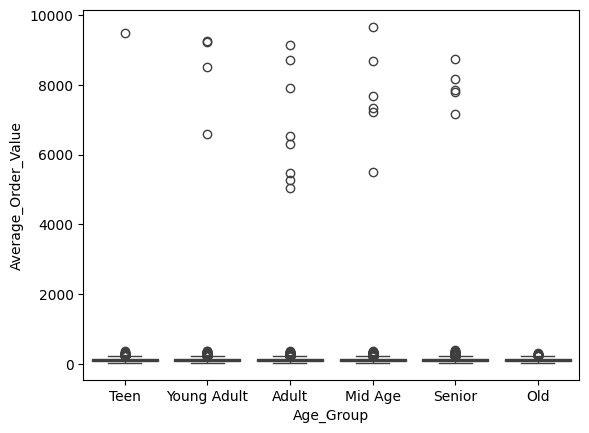

In [60]:
sns.boxplot(data=df,x="Age_Group",y="Average_Order_Value")